<a href="https://colab.research.google.com/github/DenisaEM/ProiectIA-/blob/main/ProiectIA_ZOO_with_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import the Zoo dataset from UCI Machine Learning Library**

Method 1

In [ ]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset using its ID
zoo = fetch_ucirepo(id=111)

# Data (as pandas dataframes)
X = zoo.data.features
y = zoo.data.targets

# Metadata & Variable Information
print(zoo.metadata)
print(zoo.variables)

# Features & targets
print(X)
print(y)

{'uci_id': 111, 'name': 'Zoo', 'repository_url': 'https://archive.ics.uci.edu/dataset/111/zoo', 'data_url': 'https://archive.ics.uci.edu/static/public/111/data.csv', 'abstract': 'Artificial, 7 classes of animals', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 101, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['type'], 'index_col': ['animal_name'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1990, 'last_updated': 'Fri Sep 15 2023', 'dataset_doi': '10.24432/C5R59V', 'creators': ['Richard Forsyth'], 'intro_paper': None, 'additional_info': {'summary': 'A simple database containing 17 Boolean-valued attributes.  The "type" attribute appears to be the class attribute.  Here is a breakdown of which animals are in which type: (I find it unusual that there are 2 instances of "frog" and one of "girl"!)', 'purpose': None, 'funded_by': None, 'inst

Method 2

In [ ]:
import pandas as pd

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/zoo/zoo.data"

column_names = ['animal_name', 'hair', 'feathers', 'eggs', 'milk', 'airborne', 'aquatic', 'predator', 'toothed', 'backbone',
                 'breathes', 'venomous', 'fins', 'legs', 'tail', 'domestic', 'catsize', 'type']

zoo = pd.read_csv(url, names = column_names)
print(zoo.head)

<bound method NDFrame.head of     animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0      aardvark     1         0     0     1         0        0         1   
1      antelope     1         0     0     1         0        0         0   
2          bass     0         0     1     0         0        1         1   
3          bear     1         0     0     1         0        0         1   
4          boar     1         0     0     1         0        0         1   
..          ...   ...       ...   ...   ...       ...      ...       ...   
96      wallaby     1         0     0     1         0        0         0   
97         wasp     1         0     1     0         1        0         0   
98         wolf     1         0     0     1         0        0         1   
99         worm     0         0     1     0         0        0         0   
100        wren     0         1     1     0         1        0         0   

     toothed  backbone  breathes  venomous  fins  legs  t

# **Using an alternative solution to download the dataset since UCI server and API are giving "502 Bad Gateway Error"**

To import the data I used the code snippet provided by Kaggle, where it is an official copy of the dataset made by UCI.

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "zoo.csv"
class_description = "class.csv"

# Load the latest version
zoo = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"uciml/zoo-animal-classification",file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
classes = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"uciml/zoo-animal-classification",class_description)

print(zoo)
print(classes)

Using Colab cache for faster access to the 'zoo-animal-classification' dataset.
Using Colab cache for faster access to the 'zoo-animal-classification' dataset.
    animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0      aardvark     1         0     0     1         0        0         1   
1      antelope     1         0     0     1         0        0         0   
2          bass     0         0     1     0         0        1         1   
3          bear     1         0     0     1         0        0         1   
4          boar     1         0     0     1         0        0         1   
..          ...   ...       ...   ...   ...       ...      ...       ...   
96      wallaby     1         0     0     1         0        0         0   
97         wasp     1         0     1     0         1        0         0   
98         wolf     1         0     0     1         0        0         1   
99         worm     0         0     1     0         0        0         0   
100 

# **Pre-processing the data**

**Data Quality**

In [ ]:
'''
First we verify if there are any duplicates.
Remove the column with the animal_name because we don't need it for the analysis. Also, we remove the last column because
that is what we want to predict.
'''

# Check for duplicate animal names
duplicates = zoo['animal_name'].duplicated().sum()
print(f"Number of duplicate names: {duplicates}")

# Since there are duplicates we want to keep only the first instance an animal appears
zoo_cleaned = zoo.drop_duplicates(subset='animal_name', keep='first')

# Reset the index so it goes from 0 to 99
zoo_cleaned = zoo_cleaned.reset_index(drop=True)

# Now check the last few rows
print(zoo_cleaned.tail())

# y represents what we want to find, X is the list of features, we remove the animal name column and class_type
X = zoo_cleaned.drop(columns=['animal_name', 'class_type'])
y = zoo_cleaned['class_type']

# Print first 5 rows
print(X.head)
print(y.head)

Number of duplicate names: 1
   animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
95     wallaby     1         0     0     1         0        0         0   
96        wasp     1         0     1     0         1        0         0   
97        wolf     1         0     0     1         0        0         1   
98        worm     0         0     1     0         0        0         0   
99        wren     0         1     1     0         1        0         0   

    toothed  backbone  breathes  venomous  fins  legs  tail  domestic  \
95        1         1         1         0     0     2     1         0   
96        0         0         1         1     0     6     0         0   
97        1         1         1         0     0     4     1         0   
98        0         0         1         0     0     0     0         0   
99        0         1         1         0     0     2     1         0   

    catsize  class_type  
95        1           1  
96        0           6  
97 

**Separate data train and test sets.**
 It can be observed in the original dataset that mammals have 41 instances, while classes like Amphibian and Reptile have 4, respectively 5 instances. Since we cleaned the data, and now we have 100 animals in the dataset, we want to avoid the case in which there will be no data train for classes with less animals. We make sure to keep a good 75%-25% ratio by stratifying the data.

In [ ]:
from sklearn.model_selection import train_test_split

# Separate data in training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 75
Testing set size: 25


**Method 1: Using the algorithm with the data clean data in the current shape**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report

clf=svm.SVC(kernel='rbf',C=1,gamma='scale')
clf.fit(X_train,y_train)
predictie_unscaled=clf.predict(X_test)

# See the results
print(f"Accuracy: {accuracy_score(y_test, predictie_unscaled) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, predictie_unscaled))

Accuracy: 92.00%

Classification Report:
              precision    recall  f1-score   support

           1       0.91      1.00      0.95        10
           2       1.00      1.00      1.00         5
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.92        25
   macro avg       0.67      0.71      0.69        25
weighted avg       0.85      0.92      0.88        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


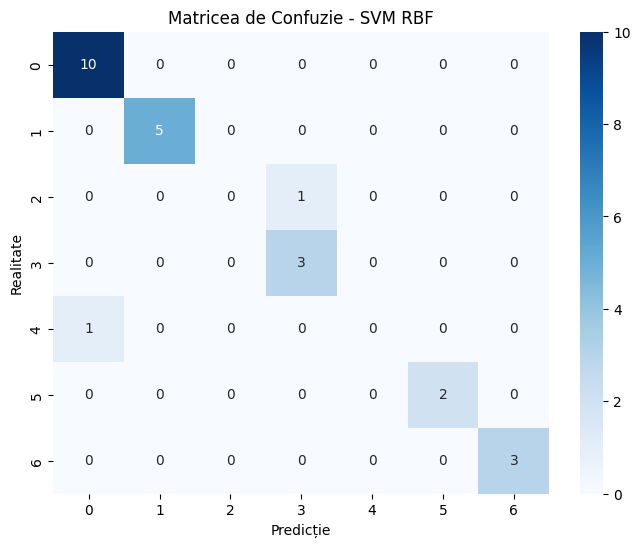

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculating the confusion matrix
cm = confusion_matrix(y_test, predictie_unscaled)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

We see in the confusion matrix that one animal from class 4 was incorectly classified and one animal from class 3. First we need to find which index is for that animal. After that we check which animal that is in the cleaned dataset.

In [ ]:
# Check what animal was incorectly clasified
for index in range(len(y_test)):
  if y_test.iloc[index] != predictie_unscaled[index]:
        # Get the actual index label from y_test
        original_animal_index = y_test.index[index]
        print(f"Predicted: {predictie_unscaled[index]}, Real: {y_test.iloc[index]}")
        print(f"Predicted class: {classes.iloc[predictie_unscaled[index]-1]['Class_Type']}, Real class: {classes.iloc[y_test.iloc[index]-1]['Class_Type']}")
        print(f"Animal:")
        display(zoo_cleaned.loc[original_animal_index].to_frame().T)

Predicted: 4, Real: 3
Predicted class: Fish, Real class: Reptile
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
79,slowworm,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,3


Predicted: 1, Real: 5
Predicted class: Mammal, Real class: Amphibian
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


**Method 1: Same algortihm with scaled data**

In [ ]:
from sklearn.preprocessing import StandardScaler
# Scale the data because the number of legs can confuse the algorithm being higher than the data in other columns
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:

import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report

model=svm.SVC(kernel='rbf',C=1,gamma='scale')
model.fit(X_train_scaled,y_train)
predictie_scaled = model.predict(X_test_scaled)

# See the results
print(f"Accuracy: {accuracy_score(y_test, predictie_scaled) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, predictie_scaled))

Accuracy: 96.00%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         5
           3       0.50      1.00      0.67         1
           4       1.00      1.00      1.00         3
           5       0.00      0.00      0.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.96        25
   macro avg       0.79      0.86      0.81        25
weighted avg       0.94      0.96      0.95        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


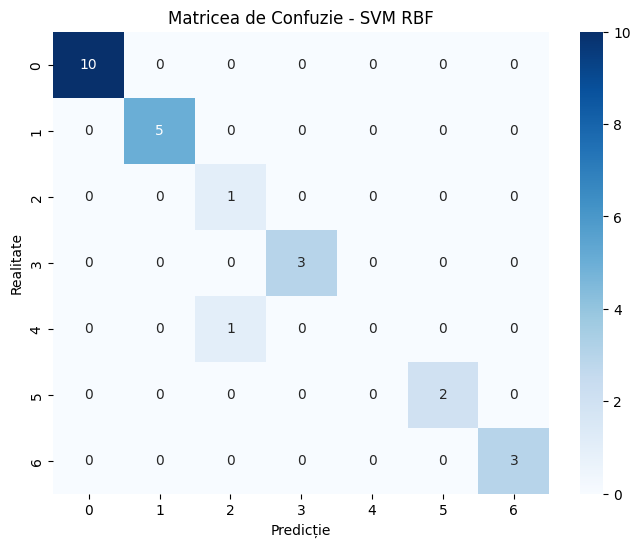

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculating the confusion matrix
cm = confusion_matrix(y_test, predictie_scaled)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

In [ ]:
# Check what animal was incorectly clasified
for index in range(len(y_test)):
  if y_test.iloc[index] != predictie_scaled[index]:
        # Get the actual index label from y_test
        original_animal_index = y_test.index[index]
        print(f"Predicted: {predictie_scaled[index]}, Real: {y_test.iloc[index]}")
        print(f"Predicted class: {classes.iloc[predictie_scaled[index]-1]['Class_Type']}, Real class: {classes.iloc[y_test.iloc[index]-1]['Class_Type']}")
        print(f"Animal:")
        display(zoo_cleaned.loc[original_animal_index].to_frame().T)

Predicted: 3, Real: 5
Predicted class: Reptile, Real class: Amphibian
Animal:


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


So the algorithm incorrectly labeled "newt" as reptile although it is an amphibian. Now, we check to see why that may be the case by checking the features associated with this classes

In [ ]:
# Check what feature may confuse the algorithm
for index in zoo_cleaned.index:
  if zoo_cleaned.loc[index]['class_type'] == 3:
    display(zoo_cleaned.loc[index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
61,pitviper,0,0,1,0,0,0,1,1,1,1,1,0,0,1,0,0,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
75,seasnake,0,0,0,0,0,1,1,1,1,0,1,0,0,1,0,0,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
79,slowworm,0,0,1,0,0,0,1,1,1,1,0,0,0,1,0,0,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
89,tortoise,0,0,1,0,0,0,0,0,1,1,0,0,4,1,0,1,3


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
90,tuatara,0,0,1,0,0,0,1,1,1,1,0,0,4,1,0,0,3


In [ ]:
# Check what feature may confuse the algorithm
for index in zoo_cleaned.index:
  if zoo_cleaned.loc[index]['class_type'] == 5:
    display(zoo_cleaned.loc[index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
25,frog,0,0,1,0,0,1,1,1,1,1,0,0,4,0,0,0,5


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
88,toad,0,0,1,0,0,1,0,1,1,1,0,0,4,0,0,0,5


We can observe that the features of tuatara are almost identical to the features of newt. Only difference being the feature for aquatic and predator. This may be a possible reason for the mislabeling, besides the small dataset disponible for those 2 classes.

In [ ]:
for original_animal_index in X_test.index:
  display(zoo_cleaned.loc[original_animal_index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
12,chub,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
76,seawasp,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,7


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
36,hawk,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
64,pony,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
22,elephant,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1


...

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
99,wren,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
14,crab,0,0,1,0,0,1,1,0,0,0,0,0,4,0,0,0,7


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
21,duck,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,0,2


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
43,leopard,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


# Checking with original data with duplicates

**Unscaled data**

Training set size: 75
Testing set size: 26
Accuracy: 96.15%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         5
           3       0.00      0.00      0.00         1
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           0.96        26
   macro avg       0.82      0.86      0.84        26
weighted avg       0.93      0.96      0.95        26



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


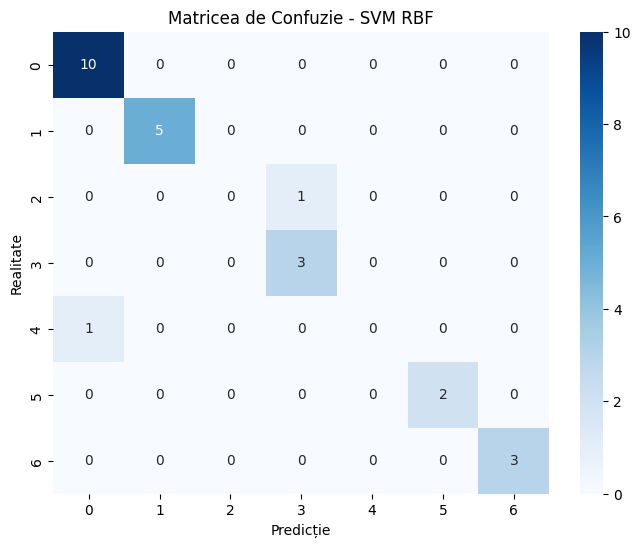

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_original = zoo.drop(columns=['animal_name', 'class_type'])
y_original = zoo['class_type']

# Separate data in training and test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_original, y_original, test_size=0.25, random_state=42, stratify=y_original)

print(f"Training set size: {X_train2.shape[0]}")
print(f"Testing set size: {X_test2.shape[0]}")

# Applying the algorithm

clf2=svm.SVC(kernel='rbf',C=1,gamma='scale')
clf2.fit(X_train2,y_train2)
predictie_unscaled2=clf2.predict(X_test2)

# See the results
print(f"Accuracy: {accuracy_score(y_test2, predictie_unscaled2) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test2, predictie_unscaled2))

# Calculating the confusion matrix
cm = confusion_matrix(y_test, predictie_unscaled)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

**Scaled data**

Training set size: 75
Testing set size: 26
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3

    accuracy                           1.00        26
   macro avg       1.00      1.00      1.00        26
weighted avg       1.00      1.00      1.00        26



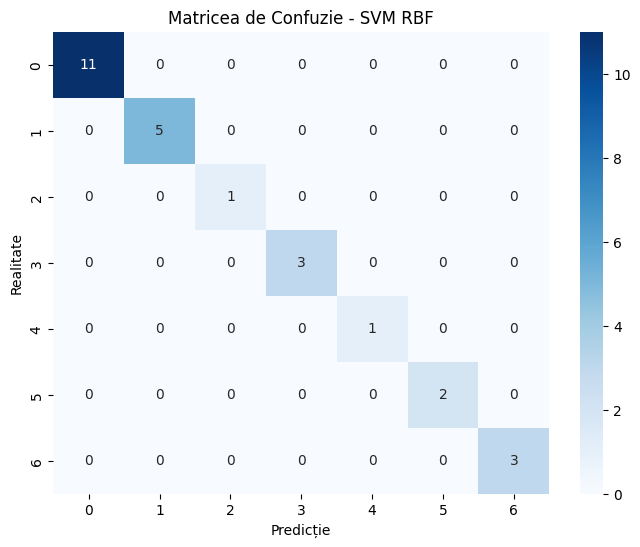

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

X_original = zoo.drop(columns=['animal_name', 'class_type'])
y_original = zoo['class_type']

# Separate data in training and test sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_original, y_original, test_size=0.25, random_state=42, stratify=y_original)

print(f"Training set size: {X_train2.shape[0]}")
print(f"Testing set size: {X_test2.shape[0]}")

# Scale the data because the number of legs can confuse the algorithm being higher than the data in other columns
sc = StandardScaler()
X_train_scaled2= sc.fit_transform(X_train2)
X_test_scaled2 = sc.transform(X_test2)

# Applying the algorithm

clf3=svm.SVC(kernel='rbf',C=1,gamma='scale')
clf3.fit(X_train_scaled2,y_train2)
predictie_scaled2=clf3.predict(X_test_scaled2)

# See the results
print(f"Accuracy: {accuracy_score(y_test2, predictie_scaled2) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test2, predictie_scaled2))

# Calculating the confusion matrix
cm = confusion_matrix(y_test2, predictie_scaled2)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicție')
plt.ylabel('Realitate')
plt.title('Matricea de Confuzie - SVM RBF')
plt.show()

In [ ]:
n_features = X_train_scaled2.shape[1]
variance_X_train_scaled = X_train_scaled2.var()
gamma_value = 1 / (n_features * variance_X_train_scaled)

print(f"The calculated gamma value when gamma='scale' for the 100% accuracy model was: {gamma_value}")

The calculated gamma value when gamma='scale' for the 100% accuracy model was: 0.0625


In [ ]:
for original_animal_index in X_test.index:
  display(zoo_cleaned.loc[original_animal_index].to_frame().T)

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
12,chub,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
76,seawasp,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,7


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
36,hawk,0,1,1,0,1,0,1,0,1,1,0,0,2,1,0,0,2


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
64,pony,1,0,0,1,0,0,0,1,1,1,0,0,4,1,1,1,1


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
22,elephant,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1


...

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
99,wren,0,1,1,0,1,0,0,0,1,1,0,0,2,1,0,0,2


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
51,newt,0,0,1,0,0,1,1,1,1,1,0,0,4,1,0,0,5


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
14,crab,0,0,1,0,0,1,1,0,0,0,0,0,4,0,0,0,7


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
21,duck,0,1,1,0,1,1,0,0,1,1,0,0,2,1,0,0,2


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
43,leopard,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1
